<a href="https://colab.research.google.com/github/gabrieldaim/QuantVisionBench/blob/main/treino_yolo_dataset_airplane_degradado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Instalar dependências
!pip install ultralytics -q
!pip install opencv-python -q
!pip install ultralytics

In [2]:
#Importações
import os
import zipfile
import shutil
from pathlib import Path
from PIL import Image

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
!ls /content/drive/MyDrive/yolo_treinos

yolo26n_airplane_fp32


In [6]:
#Baixar o datasaet https://universe.roboflow.com/aircraft-recognition/aircraft-detection-model-citoe/dataset/14#

!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="XXXXXXXXXXXXX") #Colocar a api_key aqui
project = rf.workspace("aircraft-recognition").project("aircraft-detection-model-citoe")
version = project.version(14)
dataset = version.download("yolo26")



loading Roboflow workspace...
loading Roboflow project...


In [7]:
#Validando dataset baixado

!cat {dataset.location}/data.yaml

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 28
names: ['A220', 'A300', 'A320 family', 'A330', 'A340', 'A350', 'A380', 'B737', 'B747', 'B757', 'B767 family', 'B777', 'B787', 'Beechcraft Bonanza series', 'Bombardier CRJ series', 'Bombardier Challenger series', 'C-17', 'Cessna 680', 'Cessna high-wing', 'Dassault Falcon 7X', 'E175', 'F-35', 'F-5', 'KC-135', 'Learjet series', 'MD-11', 'Piper PA-28 series', 'UH-60 family']

roboflow:
  workspace: aircraft-recognition
  project: aircraft-detection-model-citoe
  version: 14
  license: CC BY 4.0
  url: https://universe.roboflow.com/aircraft-recognition/aircraft-detection-model-citoe/dataset/14

In [ ]:
#Treinar YOLO26 nano
from ultralytics import YOLO

data_yaml = "/content/Aircraft-Detection-Model-14/data.yaml"

model = YOLO("yolo26n.pt")

results = model.train(
    data=data_yaml,
    epochs=100,
    imgsz=640,
    batch=-1,
    device=0,
    patience=10,
    cache=True,
    workers=2,
    project="/content/drive/MyDrive/yolo_treinos",
    name="yolo26n_airplane_fp32"
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Aircraft-Detection-Model-14/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolo26n_airplane_fp32-3, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, 

In [ ]:
#Para retornar
from ultralytics import YOLO
model = YOLO("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32-3/weights/last.pt")

results = model.train(
    data="/content/Aircraft-Detection-Model-14/data.yaml",
    epochs=100,
    imgsz=640,
    batch=-1,
    device=0,
    patience=10,
    cache=True,
    workers=2,
    project="/content/drive/MyDrive/yolo_treinos",
    name="yolo26n_airplane_fp32",
    resume=True
)

WARNING ⚠️ model '/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32-3/weights/last.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Aircraft-Detection-Model-14/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj

KeyboardInterrupt: 

In [8]:
# ============================================================
# PREPARAÇÃO GERAL DO BENCHMARK DE DEGRADAÇÃO
# ============================================================

!pip install -q opencv-python tqdm pyyaml

from pathlib import Path
import shutil
import yaml
import cv2
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import random

# ------------------------------------------------------------
# 1. Caminhos principais
# ------------------------------------------------------------

# dataset.location vem do download do Roboflow
SOURCE_DATASET = Path(dataset.location).resolve()

BENCHMARK_DIR = Path("/content/aircraft_benchmark")
ORIGINAL_DIR = BENCHMARK_DIR / "original"
DEGRADED_DIR = BENCHMARK_DIR / "degraded"

BENCHMARK_DIR.mkdir(parents=True, exist_ok=True)
ORIGINAL_DIR.mkdir(parents=True, exist_ok=True)
DEGRADED_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset original:", SOURCE_DATASET)
print("Pasta benchmark:", BENCHMARK_DIR)

# ------------------------------------------------------------
# 2. Classes do dataset Aircraft Detection Model v14
# ------------------------------------------------------------

CLASS_NAMES = [
    'A220',
    'A300',
    'A320 family',
    'A330',
    'A340',
    'A350',
    'A380',
    'B737',
    'B747',
    'B757',
    'B767 family',
    'B777',
    'B787',
    'Beechcraft Bonanza series',
    'Bombardier CRJ series',
    'Bombardier Challenger series',
    'C-17',
    'Cessna 680',
    'Cessna high-wing',
    'Dassault Falcon 7X',
    'E175',
    'F-35',
    'F-5',
    'KC-135',
    'Learjet series',
    'MD-11',
    'Piper PA-28 series',
    'UH-60 family'
]

NC = len(CLASS_NAMES)

print("Número de classes:", NC)

# ------------------------------------------------------------
# 3. Extensões de imagem aceitas
# ------------------------------------------------------------

IMAGE_EXTENSIONS = [".jpg", ".jpeg", ".png", ".bmp", ".webp"]

def list_images(images_dir):
    images_dir = Path(images_dir)
    files = []

    for ext in IMAGE_EXTENSIONS:
        files.extend(images_dir.glob(f"*{ext}"))
        files.extend(images_dir.glob(f"*{ext.upper()}"))

    return sorted(files)

# ------------------------------------------------------------
# 4. Criação de YAML
# ------------------------------------------------------------

def create_data_yaml(output_path, train_images, val_images, test_images):
    """
    Cria um data.yaml compatível com Ultralytics YOLO.
    Os caminhos são absolutos para evitar confusão no Colab.
    """

    data = {
        "train": str(Path(train_images).resolve()),
        "val": str(Path(val_images).resolve()),
        "test": str(Path(test_images).resolve()),
        "nc": NC,
        "names": CLASS_NAMES
    }

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    with open(output_path, "w", encoding="utf-8") as f:
        yaml.dump(data, f, sort_keys=False, allow_unicode=True)

    print(f"YAML criado: {output_path}")

# ------------------------------------------------------------
# 5. Criar YAML do dataset original
# ------------------------------------------------------------

create_data_yaml(
    output_path=ORIGINAL_DIR / "data.yaml",
    train_images=SOURCE_DATASET / "train" / "images",
    val_images=SOURCE_DATASET / "valid" / "images",
    test_images=SOURCE_DATASET / "test" / "images"
)

print("\nYAML original:")
!cat /content/aircraft_benchmark/original/data.yaml

# ------------------------------------------------------------
# 6. Funções para labels
# ------------------------------------------------------------

def copy_labels(src_labels_dir, dst_labels_dir):
    """
    Copia os arquivos .txt de labels.
    As degradações não alteram a posição dos objetos,
    então as bounding boxes continuam válidas.
    """

    src_labels_dir = Path(src_labels_dir)
    dst_labels_dir = Path(dst_labels_dir)

    dst_labels_dir.mkdir(parents=True, exist_ok=True)

    for label_file in src_labels_dir.glob("*.txt"):
        shutil.copy2(label_file, dst_labels_dir / label_file.name)

# ------------------------------------------------------------
# 7. Funções de degradação
# ------------------------------------------------------------

def apply_motion_blur(image, kernel_size):
    """
    Aplica borrão de movimento horizontal.
    kernel_size deve ser ímpar.
    """

    kernel = np.zeros((kernel_size, kernel_size), dtype=np.float32)
    kernel[kernel_size // 2, :] = np.ones(kernel_size, dtype=np.float32)
    kernel /= kernel_size

    return cv2.filter2D(image, -1, kernel)


def apply_gaussian_blur(image, kernel_size):
    """
    Aplica desfoque gaussiano.
    kernel_size deve ser ímpar.
    """

    return cv2.GaussianBlur(image, (kernel_size, kernel_size), 0)


def apply_jpeg_compression(image, quality):
    """
    Simula compressão JPEG.
    quality varia de 1 a 100.
    Quanto menor, mais degradada fica a imagem.
    """

    encode_param = [int(cv2.IMWRITE_JPEG_QUALITY), int(quality)]
    success, encoded_img = cv2.imencode(".jpg", image, encode_param)

    if not success:
        return image

    return cv2.imdecode(encoded_img, cv2.IMREAD_COLOR)


def apply_low_light(image, factor):
    """
    Reduz o brilho da imagem.
    factor menor que 1 escurece a imagem.
    """

    degraded = image.astype(np.float32) * factor
    degraded = np.clip(degraded, 0, 255).astype(np.uint8)

    return degraded


def apply_combined(image, motion_kernel, gaussian_kernel, jpeg_quality, light_factor):
    """
    Aplica degradações combinadas:
    baixa iluminação + motion blur + gaussian blur + compressão JPEG.
    """

    degraded = apply_low_light(image, light_factor)
    degraded = apply_motion_blur(degraded, motion_kernel)
    degraded = apply_gaussian_blur(degraded, gaussian_kernel)
    degraded = apply_jpeg_compression(degraded, jpeg_quality)

    return degraded

# ------------------------------------------------------------
# 8. Função genérica para gerar dataset degradado
# ------------------------------------------------------------

def generate_degraded_dataset(group_name, level_name, degradation_function):
    """
    Cria um dataset degradado para valid e test.

    Estrutura criada:

    /content/aircraft_benchmark/degraded/{group_name}/{level_name}/
    ├── valid/images
    ├── valid/labels
    ├── test/images
    ├── test/labels
    └── data.yaml
    """

    exp_dir = DEGRADED_DIR / group_name / level_name

    print("=" * 100)
    print(f"Gerando dataset degradado: {group_name}/{level_name}")
    print(f"Destino: {exp_dir}")

    for split in ["valid", "test"]:
        src_images_dir = SOURCE_DATASET / split / "images"
        src_labels_dir = SOURCE_DATASET / split / "labels"

        dst_images_dir = exp_dir / split / "images"
        dst_labels_dir = exp_dir / split / "labels"

        # limpa imagens antigas desse experimento
        if dst_images_dir.exists():
            shutil.rmtree(dst_images_dir)

        if dst_labels_dir.exists():
            shutil.rmtree(dst_labels_dir)

        dst_images_dir.mkdir(parents=True, exist_ok=True)
        dst_labels_dir.mkdir(parents=True, exist_ok=True)

        images = list_images(src_images_dir)

        print(f"\nSplit: {split}")
        print(f"Imagens encontradas: {len(images)}")

        for img_path in tqdm(images):
            image = cv2.imread(str(img_path))

            if image is None:
                print(f"Erro ao ler imagem: {img_path}")
                continue

            degraded = degradation_function(image)

            # Mantém o mesmo nome base, mas salva como .jpg
            output_path = dst_images_dir / f"{img_path.stem}.jpg"

            cv2.imwrite(str(output_path), degraded)

        copy_labels(src_labels_dir, dst_labels_dir)

    create_data_yaml(
        output_path=exp_dir / "data.yaml",
        train_images=SOURCE_DATASET / "train" / "images",
        val_images=exp_dir / "valid" / "images",
        test_images=exp_dir / "test" / "images"
    )

    print(f"\nDataset gerado com sucesso: {exp_dir}")

# ------------------------------------------------------------
# 9. Função para conferir estrutura
# ------------------------------------------------------------

def check_experiment(group_name, level_name):
    exp_dir = DEGRADED_DIR / group_name / level_name

    valid_images = list_images(exp_dir / "valid" / "images")
    valid_labels = list((exp_dir / "valid" / "labels").glob("*.txt"))

    test_images = list_images(exp_dir / "test" / "images")
    test_labels = list((exp_dir / "test" / "labels").glob("*.txt"))

    print("=" * 100)
    print(f"Experimento: {group_name}/{level_name}")
    print("Valid images:", len(valid_images))
    print("Valid labels:", len(valid_labels))
    print("Test images:", len(test_images))
    print("Test labels:", len(test_labels))
    print("YAML:", exp_dir / "data.yaml")

# ------------------------------------------------------------
# 10. Função para visualizar exemplos
# ------------------------------------------------------------

def show_image(path, title="Imagem"):
    image = cv2.imread(str(path))

    if image is None:
        print(f"Não foi possível abrir: {path}")
        return

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(8, 8))
    plt.imshow(image)
    plt.title(title)
    plt.axis("off")
    plt.show()

print("\nPreparação concluída.")

Dataset original: /content/Aircraft-Detection-Model-14
Pasta benchmark: /content/aircraft_benchmark
Número de classes: 28
YAML criado: /content/aircraft_benchmark/original/data.yaml

YAML original:
train: /content/Aircraft-Detection-Model-14/train/images
val: /content/Aircraft-Detection-Model-14/valid/images
test: /content/Aircraft-Detection-Model-14/test/images
nc: 28
names:
- A220
- A300
- A320 family
- A330
- A340
- A350
- A380
- B737
- B747
- B757
- B767 family
- B777
- B787
- Beechcraft Bonanza series
- Bombardier CRJ series
- Bombardier Challenger series
- C-17
- Cessna 680
- Cessna high-wing
- Dassault Falcon 7X
- E175
- F-35
- F-5
- KC-135
- Learjet series
- MD-11
- Piper PA-28 series
- UH-60 family

Preparação concluída.


In [8]:
# ============================================================
# MOTION BLUR
# ============================================================

motion_blur_levels = {
    "light": 5,
    "medium": 11,
    "heavy": 21
}

for level_name, kernel_size in motion_blur_levels.items():
    generate_degraded_dataset(
        group_name="motion_blur",
        level_name=level_name,
        degradation_function=lambda image, k=kernel_size: apply_motion_blur(image, k)
    )

    check_experiment("motion_blur", level_name)

Gerando dataset degradado: motion_blur/light
Destino: /content/aircraft_benchmark/degraded/motion_blur/light

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:03<00:00, 212.34it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:02<00:00, 168.56it/s]


YAML criado: /content/aircraft_benchmark/degraded/motion_blur/light/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/motion_blur/light
Experimento: motion_blur/light
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/motion_blur/light/data.yaml
Gerando dataset degradado: motion_blur/medium
Destino: /content/aircraft_benchmark/degraded/motion_blur/medium

Split: valid
Imagens encontradas: 830


...

YAML criado: /content/aircraft_benchmark/degraded/motion_blur/medium/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/motion_blur/medium
Experimento: motion_blur/medium
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/motion_blur/medium/data.yaml
Gerando dataset degradado: motion_blur/heavy
Destino: /content/aircraft_benchmark/degraded/motion_blur/heavy

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:11<00:00, 71.31it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:05<00:00, 75.33it/s]


YAML criado: /content/aircraft_benchmark/degraded/motion_blur/heavy/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/motion_blur/heavy
Experimento: motion_blur/heavy
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/motion_blur/heavy/data.yaml


In [9]:
# ============================================================
# GAUSSIAN BLUR
# ============================================================

gaussian_blur_levels = {
    "light": 3,
    "medium": 7,
    "heavy": 11
}

for level_name, kernel_size in gaussian_blur_levels.items():
    generate_degraded_dataset(
        group_name="gaussian_blur",
        level_name=level_name,
        degradation_function=lambda image, k=kernel_size: apply_gaussian_blur(image, k)
    )

    check_experiment("gaussian_blur", level_name)

Gerando dataset degradado: gaussian_blur/light
Destino: /content/aircraft_benchmark/degraded/gaussian_blur/light

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:01<00:00, 421.79it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:00<00:00, 425.08it/s]


YAML criado: /content/aircraft_benchmark/degraded/gaussian_blur/light/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/gaussian_blur/light
Experimento: gaussian_blur/light
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/gaussian_blur/light/data.yaml
Gerando dataset degradado: gaussian_blur/medium
Destino: /content/aircraft_benchmark/degraded/gaussian_blur/medium

Split: valid
Imagens encontradas: 830


...

YAML criado: /content/aircraft_benchmark/degraded/gaussian_blur/medium/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/gaussian_blur/medium
Experimento: gaussian_blur/medium
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/gaussian_blur/medium/data.yaml
Gerando dataset degradado: gaussian_blur/heavy
Destino: /content/aircraft_benchmark/degraded/gaussian_blur/heavy

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:03<00:00, 251.80it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:01<00:00, 282.03it/s]

YAML criado: /content/aircraft_benchmark/degraded/gaussian_blur/heavy/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/gaussian_blur/heavy
Experimento: gaussian_blur/heavy
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/gaussian_blur/heavy/data.yaml


In [10]:
# ============================================================
# JPEG COMPRESSION
# ============================================================

jpeg_compression_levels = {
    "light": 70,
    "medium": 40,
    "heavy": 20
}

for level_name, quality in jpeg_compression_levels.items():
    generate_degraded_dataset(
        group_name="jpeg_compression",
        level_name=level_name,
        degradation_function=lambda image, q=quality: apply_jpeg_compression(image, q)
    )

    check_experiment("jpeg_compression", level_name)

Gerando dataset degradado: jpeg_compression/light
Destino: /content/aircraft_benchmark/degraded/jpeg_compression/light

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:02<00:00, 286.78it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:01<00:00, 278.57it/s]


YAML criado: /content/aircraft_benchmark/degraded/jpeg_compression/light/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/jpeg_compression/light
Experimento: jpeg_compression/light
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/jpeg_compression/light/data.yaml
Gerando dataset degradado: jpeg_compression/medium
Destino: /content/aircraft_benchmark/degraded/jpeg_compression/medium

Split: valid
Imagens encontradas: 830


...

YAML criado: /content/aircraft_benchmark/degraded/jpeg_compression/medium/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/jpeg_compression/medium
Experimento: jpeg_compression/medium
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/jpeg_compression/medium/data.yaml
Gerando dataset degradado: jpeg_compression/heavy
Destino: /content/aircraft_benchmark/degraded/jpeg_compression/heavy

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:02<00:00, 316.92it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:01<00:00, 316.12it/s]


YAML criado: /content/aircraft_benchmark/degraded/jpeg_compression/heavy/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/jpeg_compression/heavy
Experimento: jpeg_compression/heavy
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/jpeg_compression/heavy/data.yaml


In [11]:
# ============================================================
# LOW LIGHT
# ============================================================

low_light_levels = {
    "light": 0.80,
    "medium": 0.60,
    "heavy": 0.40
}

for level_name, factor in low_light_levels.items():
    generate_degraded_dataset(
        group_name="low_light",
        level_name=level_name,
        degradation_function=lambda image, f=factor: apply_low_light(image, f)
    )

    check_experiment("low_light", level_name)

Gerando dataset degradado: low_light/light
Destino: /content/aircraft_benchmark/degraded/low_light/light

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:03<00:00, 241.60it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:01<00:00, 326.46it/s]


YAML criado: /content/aircraft_benchmark/degraded/low_light/light/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/low_light/light
Experimento: low_light/light
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/low_light/light/data.yaml
Gerando dataset degradado: low_light/medium
Destino: /content/aircraft_benchmark/degraded/low_light/medium

Split: valid
Imagens encontradas: 830


...

YAML criado: /content/aircraft_benchmark/degraded/low_light/medium/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/low_light/medium
Experimento: low_light/medium
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/low_light/medium/data.yaml
Gerando dataset degradado: low_light/heavy
Destino: /content/aircraft_benchmark/degraded/low_light/heavy

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:02<00:00, 325.14it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:01<00:00, 328.06it/s]

YAML criado: /content/aircraft_benchmark/degraded/low_light/heavy/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/low_light/heavy
Experimento: low_light/heavy
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/low_light/heavy/data.yaml


In [12]:
# ============================================================
# COMBINED
# ============================================================

combined_levels = {
    "light": {
        "motion_kernel": 5,
        "gaussian_kernel": 3,
        "jpeg_quality": 70,
        "light_factor": 0.80
    },
    "medium": {
        "motion_kernel": 11,
        "gaussian_kernel": 7,
        "jpeg_quality": 40,
        "light_factor": 0.60
    },
    "heavy": {
        "motion_kernel": 21,
        "gaussian_kernel": 11,
        "jpeg_quality": 20,
        "light_factor": 0.40
    }
}

for level_name, params in combined_levels.items():
    generate_degraded_dataset(
        group_name="combined",
        level_name=level_name,
        degradation_function=lambda image, p=params: apply_combined(
            image,
            motion_kernel=p["motion_kernel"],
            gaussian_kernel=p["gaussian_kernel"],
            jpeg_quality=p["jpeg_quality"],
            light_factor=p["light_factor"]
        )
    )

    check_experiment("combined", level_name)

Gerando dataset degradado: combined/light
Destino: /content/aircraft_benchmark/degraded/combined/light

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:04<00:00, 177.35it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:03<00:00, 134.69it/s]


YAML criado: /content/aircraft_benchmark/degraded/combined/light/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/combined/light
Experimento: combined/light
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/combined/light/data.yaml
Gerando dataset degradado: combined/medium
Destino: /content/aircraft_benchmark/degraded/combined/medium

Split: valid
Imagens encontradas: 830


...

YAML criado: /content/aircraft_benchmark/degraded/combined/medium/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/combined/medium
Experimento: combined/medium
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/combined/medium/data.yaml
Gerando dataset degradado: combined/heavy
Destino: /content/aircraft_benchmark/degraded/combined/heavy

Split: valid
Imagens encontradas: 830


100%|██████████| 830/830 [00:15<00:00, 54.94it/s]



Split: test
Imagens encontradas: 413


100%|██████████| 413/413 [00:07<00:00, 52.10it/s]


YAML criado: /content/aircraft_benchmark/degraded/combined/heavy/data.yaml

Dataset gerado com sucesso: /content/aircraft_benchmark/degraded/combined/heavy
Experimento: combined/heavy
Valid images: 830
Valid labels: 830
Test images: 413
Test labels: 413
YAML: /content/aircraft_benchmark/degraded/combined/heavy/data.yaml


Imagem escolhida: 19-Minutes-of-Planespotting-at-Ontario-International-Airport_mp4-1169_jpg.rf.2ecf7d9eda43935b5a1c9fc36f47f752.jpg


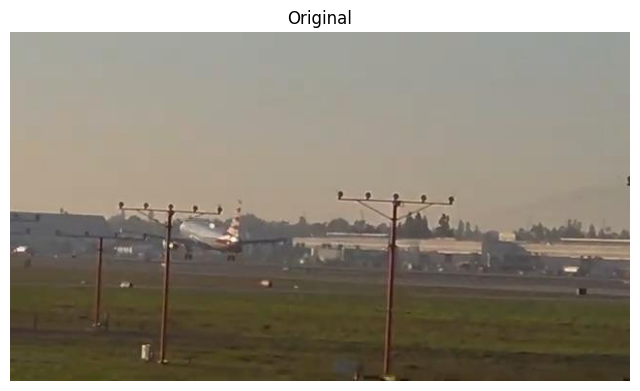

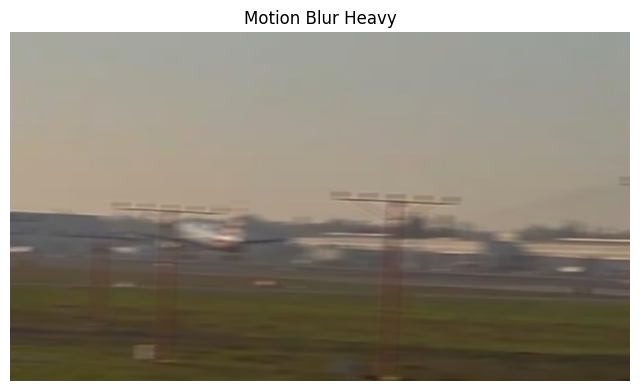

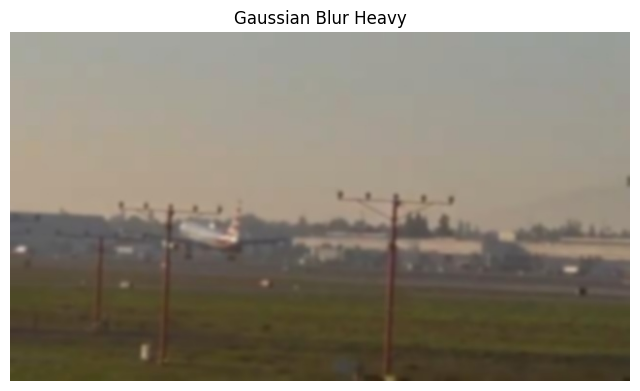

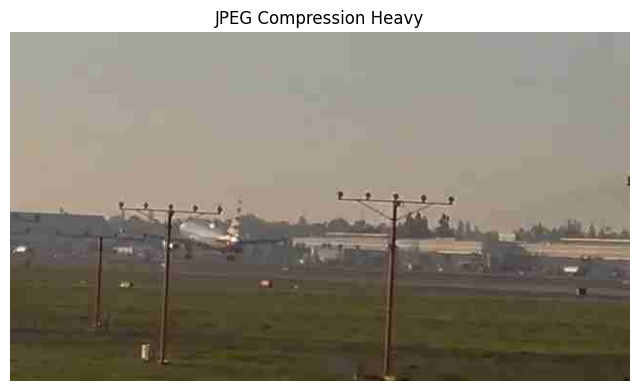

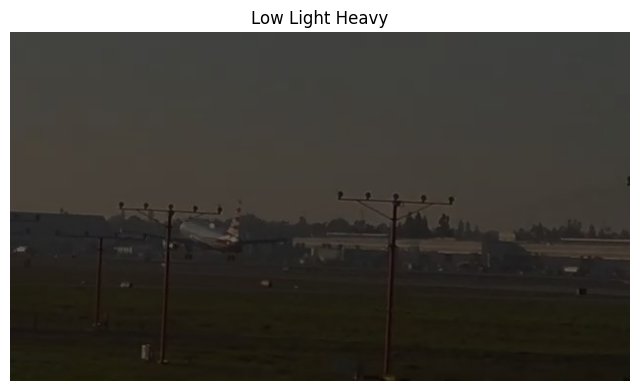

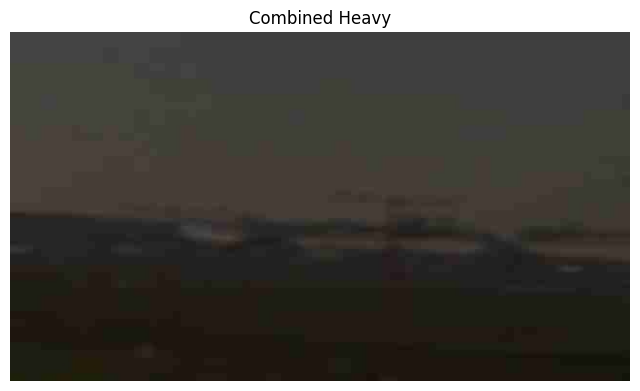

In [13]:
# ============================================================
# VISUALIZAÇÃO DE EXEMPLOS
# ============================================================

original_images = list_images(SOURCE_DATASET / "valid" / "images")
sample_original = random.choice(original_images)

sample_name = sample_original.stem + ".jpg"

print("Imagem escolhida:", sample_original.name)

show_image(sample_original, "Original")

examples = [
    ("Motion Blur Heavy", DEGRADED_DIR / "motion_blur" / "heavy" / "valid" / "images" / sample_name),
    ("Gaussian Blur Heavy", DEGRADED_DIR / "gaussian_blur" / "heavy" / "valid" / "images" / sample_name),
    ("JPEG Compression Heavy", DEGRADED_DIR / "jpeg_compression" / "heavy" / "valid" / "images" / sample_name),
    ("Low Light Heavy", DEGRADED_DIR / "low_light" / "heavy" / "valid" / "images" / sample_name),
    ("Combined Heavy", DEGRADED_DIR / "combined" / "heavy" / "valid" / "images" / sample_name),
]

for title, path in examples:
    if path.exists():
        show_image(path, title)
    else:
        print(f"Imagem não encontrada: {path}")

In [18]:
from pathlib import Path
import shutil
import os

# ============================================================
# PASTAS PRINCIPAIS
# ============================================================

# Pasta base dos resultados no Google Drive
RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")

# Pasta dos modelos
MODELS_DIR = RESULTS_ROOT / "models"

# Pasta dos relatórios
REPORTS_DIR = RESULTS_ROOT / "reports"

# Subpastas dos modelos
FP32_MODEL_DIR = MODELS_DIR / "fp32"
INT8_OPENVINO_MODEL_DIR = MODELS_DIR / "int8_openvino"
INT8_TENSORRT_MODEL_DIR = MODELS_DIR / "int8_tensorrt"

# Subpastas dos relatórios
SCENARIO_REPORT_DIRS = {
    "gpu_fp32": REPORTS_DIR / "gpu_fp32",
    "gpu_int8": REPORTS_DIR / "gpu_int8",
    "cpu_fp32": REPORTS_DIR / "cpu_fp32",
    "cpu_int8": REPORTS_DIR / "cpu_int8",
}

# Criar estrutura
for path in [
    RESULTS_ROOT,
    MODELS_DIR,
    REPORTS_DIR,
    FP32_MODEL_DIR,
    INT8_OPENVINO_MODEL_DIR,
    INT8_TENSORRT_MODEL_DIR,
    *SCENARIO_REPORT_DIRS.values()
]:
    path.mkdir(parents=True, exist_ok=True)

for scenario, path in SCENARIO_REPORT_DIRS.items():
    (path / "plots").mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(RESULTS_ROOT)

# ============================================================
# CAMINHOS DOS MODELOS
# ============================================================

# Modelo FP32 treinado
FP32_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt")

# Modelo INT8 OpenVINO, recomendado para CPU
INT8_OPENVINO_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best_int8_openvino_model")

# Modelo INT8 TensorRT, recomendado para GPU NVIDIA
INT8_TENSORRT_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best_int8.engine")

print("FP32:", FP32_MODEL_PATH)
print("INT8 OpenVINO:", INT8_OPENVINO_MODEL_PATH)
print("INT8 TensorRT:", INT8_TENSORRT_MODEL_PATH)

# ============================================================
# DATASETS DE VALIDAÇÃO
# ============================================================

DATASET_YAMLS = {
    "original": {
        "degradation": "original",
        "level": "baseline",
        "yaml": "/content/aircraft_benchmark/original/data.yaml"
    },

    "motion_blur_light": {
        "degradation": "motion_blur",
        "level": "light",
        "yaml": "/content/aircraft_benchmark/degraded/motion_blur/light/data.yaml"
    },
    "motion_blur_medium": {
        "degradation": "motion_blur",
        "level": "medium",
        "yaml": "/content/aircraft_benchmark/degraded/motion_blur/medium/data.yaml"
    },
    "motion_blur_heavy": {
        "degradation": "motion_blur",
        "level": "heavy",
        "yaml": "/content/aircraft_benchmark/degraded/motion_blur/heavy/data.yaml"
    },

    "gaussian_blur_light": {
        "degradation": "gaussian_blur",
        "level": "light",
        "yaml": "/content/aircraft_benchmark/degraded/gaussian_blur/light/data.yaml"
    },
    "gaussian_blur_medium": {
        "degradation": "gaussian_blur",
        "level": "medium",
        "yaml": "/content/aircraft_benchmark/degraded/gaussian_blur/medium/data.yaml"
    },
    "gaussian_blur_heavy": {
        "degradation": "gaussian_blur",
        "level": "heavy",
        "yaml": "/content/aircraft_benchmark/degraded/gaussian_blur/heavy/data.yaml"
    },

    "jpeg_compression_light": {
        "degradation": "jpeg_compression",
        "level": "light",
        "yaml": "/content/aircraft_benchmark/degraded/jpeg_compression/light/data.yaml"
    },
    "jpeg_compression_medium": {
        "degradation": "jpeg_compression",
        "level": "medium",
        "yaml": "/content/aircraft_benchmark/degraded/jpeg_compression/medium/data.yaml"
    },
    "jpeg_compression_heavy": {
        "degradation": "jpeg_compression",
        "level": "heavy",
        "yaml": "/content/aircraft_benchmark/degraded/jpeg_compression/heavy/data.yaml"
    },

    "low_light_light": {
        "degradation": "low_light",
        "level": "light",
        "yaml": "/content/aircraft_benchmark/degraded/low_light/light/data.yaml"
    },
    "low_light_medium": {
        "degradation": "low_light",
        "level": "medium",
        "yaml": "/content/aircraft_benchmark/degraded/low_light/medium/data.yaml"
    },
    "low_light_heavy": {
        "degradation": "low_light",
        "level": "heavy",
        "yaml": "/content/aircraft_benchmark/degraded/low_light/heavy/data.yaml"
    },

    "combined_light": {
        "degradation": "combined",
        "level": "light",
        "yaml": "/content/aircraft_benchmark/degraded/combined/light/data.yaml"
    },
    "combined_medium": {
        "degradation": "combined",
        "level": "medium",
        "yaml": "/content/aircraft_benchmark/degraded/combined/medium/data.yaml"
    },
    "combined_heavy": {
        "degradation": "combined",
        "level": "heavy",
        "yaml": "/content/aircraft_benchmark/degraded/combined/heavy/data.yaml"
    },
}

# Conferência rápida
for name, info in DATASET_YAMLS.items():
    yaml_path = Path(info["yaml"])
    if not yaml_path.exists():
        print(f"[ERRO] YAML não encontrado: {name} -> {yaml_path}")
    else:
        print(f"[OK] {name}: {yaml_path}")

Estrutura criada em:
/content/drive/MyDrive/aircraft_benchmark_results
FP32: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt
INT8 OpenVINO: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best_int8_openvino_model
INT8 TensorRT: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best_int8.engine
[OK] original: /content/aircraft_benchmark/original/data.yaml
[OK] motion_blur_light: /content/aircraft_benchmark/degraded/motion_blur/light/data.yaml
[OK] motion_blur_medium: /content/aircraft_benchmark/degraded/motion_blur/medium/data.yaml
[OK] motion_blur_heavy: /content/aircraft_benchmark/degraded/motion_blur/heavy/data.yaml
[OK] gaussian_blur_light: /content/aircraft_benchmark/degraded/gaussian_blur/light/data.yaml
[OK] gaussian_blur_medium: /content/aircraft_benchmark/degraded/gaussian_blur/medium/data.yaml
[OK] gaussian_blur_heavy: /content/aircraft_benchmark/degraded/gaussian_blur/heavy/data.yaml
[OK] jpeg_compression_light: /con

In [29]:
from ultralytics import YOLO
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path
import platform
import torch

# ============================================================
# CONFIGURAÇÕES GERAIS
# ============================================================

N_RUNS = 3
IMGSZ = 640

LEVEL_ORDER = {
    "baseline": 0,
    "light": 1,
    "medium": 2,
    "heavy": 3
}

LEVEL_LABELS = {
    "baseline": "Original",
    "light": "Leve",
    "medium": "Média",
    "heavy": "Pesada"
}

DEGRADATION_LABELS = {
    "original": "Original",
    "motion_blur": "Motion Blur",
    "gaussian_blur": "Gaussian Blur",
    "jpeg_compression": "JPEG Compression",
    "low_light": "Low Light",
    "combined": "Combined"
}

# ============================================================
# INFORMAÇÕES DO AMBIENTE
# ============================================================

def get_environment_info(device):
    gpu_available = torch.cuda.is_available()

    if gpu_available:
        gpu_name = torch.cuda.get_device_name(0)
    else:
        gpu_name = "N/A"

    return {
        "python_version": platform.python_version(),
        "torch_version": torch.__version__,
        "cuda_available": gpu_available,
        "gpu_name": gpu_name,
        "device_requested": device
    }

# ============================================================
# EXTRAÇÃO DE MÉTRICAS DO ULTRALYTICS
# ============================================================

def extract_metrics(metrics):
    result = metrics.results_dict

    speed = getattr(metrics, "speed", {})

    preprocess_ms = speed.get("preprocess", None)
    inference_ms = speed.get("inference", None)
    postprocess_ms = speed.get("postprocess", None)

    total_ms = None
    fps = None

    if inference_ms is not None:
        total_ms = 0

        if preprocess_ms is not None:
            total_ms += preprocess_ms

        total_ms += inference_ms

        if postprocess_ms is not None:
            total_ms += postprocess_ms

        if total_ms > 0:
            fps = 1000 / total_ms

    return {
        "precision": result.get("metrics/precision(B)"),
        "recall": result.get("metrics/recall(B)"),
        "mAP50": result.get("metrics/mAP50(B)"),
        "mAP50_95": result.get("metrics/mAP50-95(B)"),
        "fitness": result.get("fitness"),
        "preprocess_ms": preprocess_ms,
        "inference_ms": inference_ms,
        "postprocess_ms": postprocess_ms,
        "total_ms": total_ms,
        "fps": fps
    }

# ============================================================
# VALIDAÇÃO DE UM CENÁRIO COMPLETO
# ============================================================

def run_validation_scenario(
    scenario_name,
    model_path,
    device,
    report_dir,
    n_runs=3,
    imgsz=640
):
    """
    Roda validação para todos os datasets:
    - original
    - degradações light/medium/heavy

    Salva:
    - raw_results.csv
    - summary_results.csv
    - summary_results.xlsx
    - gráficos
    """

    report_dir = Path(report_dir)
    plots_dir = report_dir / "plots"
    report_dir.mkdir(parents=True, exist_ok=True)
    plots_dir.mkdir(parents=True, exist_ok=True)

    env_info = get_environment_info(device)

    print("=" * 100)
    print(f"Cenário: {scenario_name}")
    print(f"Modelo: {model_path}")
    print(f"Device: {device}")
    print(f"Relatórios: {report_dir}")
    print("=" * 100)

    if not Path(model_path).exists():
        raise FileNotFoundError(f"Modelo não encontrado: {model_path}")

    raw_results = []

    model = YOLO(str(model_path))

    for dataset_name, dataset_info in DATASET_YAMLS.items():
        yaml_path = Path(dataset_info["yaml"])

        if not yaml_path.exists():
            print(f"[ERRO] YAML não encontrado: {dataset_name} -> {yaml_path}")
            continue

        for run_id in range(1, n_runs + 1):
            print("-" * 100)
            print(f"Cenário: {scenario_name}")
            print(f"Dataset: {dataset_name}")
            print(f"Run: {run_id}/{n_runs}")
            print(f"YAML: {yaml_path}")

            start_time = time.time()

            metrics = model.val(
                data=str(yaml_path),
                imgsz=imgsz,
                device=device,
                batch=1,
                plots=False,
                verbose=False,
                name=f"{scenario_name}_{dataset_name}_run{run_id}"
            )

            elapsed_seconds = time.time() - start_time

            metric_values = extract_metrics(metrics)

            row = {
                "scenario": scenario_name,
                "model_path": str(model_path),
                "dataset": dataset_name,
                "degradation": dataset_info["degradation"],
                "level": dataset_info["level"],
                "level_order": LEVEL_ORDER[dataset_info["level"]],
                "run": run_id,
                "imgsz": imgsz,
                "device": str(device),
                "elapsed_seconds": elapsed_seconds,
                **metric_values,
                **env_info
            }

            raw_results.append(row)

    df_raw = pd.DataFrame(raw_results)

    raw_csv_path = report_dir / "raw_results.csv"
    df_raw.to_csv(raw_csv_path, index=False)

    print(f"Resultados brutos salvos em: {raw_csv_path}")

    df_summary = create_summary_table(df_raw)

    summary_csv_path = report_dir / "summary_results.csv"
    summary_xlsx_path = report_dir / "summary_results.xlsx"

    df_summary.to_csv(summary_csv_path, index=False)

    with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
        df_raw.to_excel(writer, sheet_name="raw_results", index=False)
        df_summary.to_excel(writer, sheet_name="summary_results", index=False)

    print(f"Resumo salvo em: {summary_csv_path}")
    print(f"Planilha salva em: {summary_xlsx_path}")

    generate_plots(df_summary, plots_dir, scenario_name)

    return df_raw, df_summary

# ============================================================
# TABELA CONSOLIDADA
# ============================================================

def create_summary_table(df_raw):
    numeric_cols = [
        "precision",
        "recall",
        "mAP50",
        "mAP50_95",
        "preprocess_ms",
        "inference_ms",
        "postprocess_ms",
        "total_ms",
        "fps",
        "elapsed_seconds"
    ]

    grouped = df_raw.groupby(
        ["scenario", "degradation", "level", "level_order", "dataset"],
        as_index=False
    )[numeric_cols].agg(["mean", "std"])

    grouped.columns = [
        "_".join(col).strip("_") if isinstance(col, tuple) else col
        for col in grouped.columns
    ]

    df_summary = grouped.sort_values(
        by=["degradation", "level_order"]
    ).reset_index(drop=True)

    # baseline original
    baseline = df_summary[df_summary["degradation"] == "original"].iloc[0]

    baseline_map50 = baseline["mAP50_mean"]
    baseline_map5095 = baseline["mAP50_95_mean"]
    baseline_fps = baseline["fps_mean"]

    df_summary["drop_mAP50_percent"] = (
        (baseline_map50 - df_summary["mAP50_mean"]) / baseline_map50
    ) * 100

    df_summary["drop_mAP50_95_percent"] = (
        (baseline_map5095 - df_summary["mAP50_95_mean"]) / baseline_map5095
    ) * 100

    df_summary["fps_change_percent"] = (
        (df_summary["fps_mean"] - baseline_fps) / baseline_fps
    ) * 100

    return df_summary

# ============================================================
# GRÁFICOS
# ============================================================

def generate_plots(df_summary, plots_dir, scenario_name):
    plots_dir = Path(plots_dir)
    plots_dir.mkdir(parents=True, exist_ok=True)

    df_plot = df_summary.copy()

    # Remove original dos gráficos por degradação, exceto onde necessário
    degradation_order = [
        "motion_blur",
        "gaussian_blur",
        "jpeg_compression",
        "low_light",
        "combined"
    ]

    # --------------------------------------------------------
    # 1. mAP50 por nível
    # --------------------------------------------------------

    plt.figure(figsize=(10, 6))

    baseline_map50 = df_plot[df_plot["degradation"] == "original"]["mAP50_mean"].values[0]

    for degradation in degradation_order:
        temp = df_plot[df_plot["degradation"] == degradation].sort_values("level_order")

        x = [0] + temp["level_order"].tolist()
        y = [baseline_map50] + temp["mAP50_mean"].tolist()

        labels = ["Original"] + [LEVEL_LABELS[l] for l in temp["level"].tolist()]

        plt.plot(x, y, marker="o", label=DEGRADATION_LABELS[degradation])

    plt.xticks([0, 1, 2, 3], ["Original", "Leve", "Média", "Pesada"])
    plt.xlabel("Nível de degradação")
    plt.ylabel("mAP50")
    plt.title(f"{scenario_name} - mAP50 por nível de degradação")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plots_dir / "map50_by_degradation_level.png", dpi=300)
    plt.close()

    # --------------------------------------------------------
    # 2. mAP50-95 por nível
    # --------------------------------------------------------

    plt.figure(figsize=(10, 6))

    baseline_map5095 = df_plot[df_plot["degradation"] == "original"]["mAP50_95_mean"].values[0]

    for degradation in degradation_order:
        temp = df_plot[df_plot["degradation"] == degradation].sort_values("level_order")

        x = [0] + temp["level_order"].tolist()
        y = [baseline_map5095] + temp["mAP50_95_mean"].tolist()

        plt.plot(x, y, marker="o", label=DEGRADATION_LABELS[degradation])

    plt.xticks([0, 1, 2, 3], ["Original", "Leve", "Média", "Pesada"])
    plt.xlabel("Nível de degradação")
    plt.ylabel("mAP50-95")
    plt.title(f"{scenario_name} - mAP50-95 por nível de degradação")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plots_dir / "map50_95_by_degradation_level.png", dpi=300)
    plt.close()

    # --------------------------------------------------------
    # 3. Queda percentual no nível pesado
    # --------------------------------------------------------

    heavy = df_plot[df_plot["level"] == "heavy"].copy()
    heavy = heavy[heavy["degradation"] != "original"]

    plt.figure(figsize=(10, 6))
    plt.bar(
        [DEGRADATION_LABELS[d] for d in heavy["degradation"]],
        heavy["drop_mAP50_percent"]
    )
    plt.xlabel("Tipo de degradação")
    plt.ylabel("Queda mAP50 (%)")
    plt.title(f"{scenario_name} - Queda percentual de mAP50 no nível pesado")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(plots_dir / "drop_map50_heavy.png", dpi=300)
    plt.close()

    # --------------------------------------------------------
    # 4. FPS médio por dataset
    # --------------------------------------------------------

    plt.figure(figsize=(12, 6))
    plt.bar(df_plot["dataset"], df_plot["fps_mean"])
    plt.xlabel("Dataset")
    plt.ylabel("FPS médio")
    plt.title(f"{scenario_name} - FPS médio por dataset")
    plt.xticks(rotation=75, ha="right")
    plt.tight_layout()
    plt.savefig(plots_dir / "fps_by_dataset.png", dpi=300)
    plt.close()

    # --------------------------------------------------------
    # 5. Trade-off FPS x mAP50-95
    # --------------------------------------------------------

    plt.figure(figsize=(8, 6))
    plt.scatter(df_plot["fps_mean"], df_plot["mAP50_95_mean"])

    for _, row in df_plot.iterrows():
        plt.annotate(
            row["dataset"],
            (row["fps_mean"], row["mAP50_95_mean"]),
            fontsize=7
        )

    plt.xlabel("FPS médio")
    plt.ylabel("mAP50-95 médio")
    plt.title(f"{scenario_name} - Trade-off desempenho x acurácia")
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(plots_dir / "tradeoff_fps_map50_95.png", dpi=300)
    plt.close()

    print(f"Gráficos salvos em: {plots_dir}")

In [16]:
# ============================================================
# CENÁRIO 1 — GPU + FP32
# ============================================================

df_gpu_fp32_raw, df_gpu_fp32_summary = run_validation_scenario(
    scenario_name="gpu_fp32",
    model_path=FP32_MODEL_PATH,
    device=0,
    report_dir=SCENARIO_REPORT_DIRS["gpu_fp32"],
    n_runs=N_RUNS,
    imgsz=IMGSZ
)

df_gpu_fp32_summary

Cenário: gpu_fp32
Modelo: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt
Device: 0
Relatórios: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32
----------------------------------------------------------------------------------------------------
Cenário: gpu_fp32
Dataset: original
Run: 1/3
YAML: /content/aircraft_benchmark/original/data.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,380,296 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 696.3±405.9 MB/s, size: 13.7 KB)
val: Scanning /content/Aircraft-Detection-Model-14/valid/labels... 830 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830 2.3Kit/s 0.4s
val: New cache created: /content/Aircraft-Detection-Model-14/valid/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 185, len(boxes) = 876. To resolve this only boxes will be used 

,scenario,degradation,level,level_order,dataset,precision_mean,precision_std,recall_mean,recall_std,mAP50_mean,...,postprocess_ms_std,total_ms_mean,total_ms_std,fps_mean,fps_std,elapsed_seconds_mean,elapsed_seconds_std,drop_mAP50_percent,drop_mAP50_95_percent,fps_change_percent
0,gpu_fp32,combined,light,1,combined_light,0.885627,0.0,0.853965,0.0,0.915018,...,0.004728,15.622591,0.127807,64.012734,0.525626,17.122704,0.094793,2.362391,4.104278,3.097631
1,gpu_fp32,combined,medium,2,combined_medium,0.749595,0.0,0.710775,0.0,0.806471,...,0.005640,15.843050,0.408713,63.146817,1.608168,17.489661,0.810091,13.945033,21.108922,1.703002
2,gpu_fp32,combined,heavy,3,combined_heavy,0.541379,0.0,0.235811,0.0,0.219326,...,0.002384,15.088922,0.101994,66.275798,0.446316,16.532617,0.244700,76.596655,84.291690,6.742477
3,gpu_fp32,gaussian_blur,light,1,gaussian_blur_light,0.916267,0.0,0.861056,0.0,0.920463,...,0.014123,15.050324,0.972872,66.626042,4.232273,16.593205,1.348172,1.781388,2.051479,7.306573
4,gpu_fp32,gaussian_blur,medium,2,gaussian_blur_medium,0.871071,0.0,0.850620,0.0,0.893288,...,0.003339,14.670646,0.094006,68.165188,0.436602,16.113390,0.260489,4.681123,5.672986,9.785491
5,gpu_fp32,gaussian_blur,heavy,3,gaussian_blur_heavy,0.793932,0.0,0.865432,0.0,0.883997,...,0.004043,14.749549,0.182588,67.805605,0.838620,16.256881,0.127164,5.672555,9.352269,9.206353
6,gpu_fp32,jpeg_compression,light,1,jpeg_compression_light,0.904906,0.0,0.881145,0.0,0.938020,...,0.004348,14.485580,0.157937,69.039623,0.750023,15.941879,0.439707,-0.092016,0.297815,11.193838
7,gpu_fp32,jpeg_compression,medium,2,jpeg_compression_medium,0.881728,0.0,0.881351,0.0,0.925024,...,0.010815,15.401264,0.437139,64.964612,1.843458,16.959388,0.290035,1.294760,1.439491,4.630707
8,gpu_fp32,jpeg_compression,heavy,3,jpeg_compression_heavy,0.929907,0.0,0.846734,0.0,0.917389,...,0.001833,15.654916,0.255263,63.889130,1.051623,17.303342,0.580967,2.109451,4.647808,2.898557
9,gpu_fp32,low_light,light,1,low_light_light,0.902715,0.0,0.863962,0.0,0.927811,...,0.007310,16.155987,0.359970,61.917023,1.377919,17.779225,0.252582,0.997368,1.887615,-0.277679


In [18]:
from pathlib import Path
import pandas as pd
import shutil

# ============================================================
# SALVAR RESULTADOS JÁ GERADOS — GPU + FP32
# ============================================================

SCENARIO_NAME = "gpu_fp32"

# Pasta raiz no Drive
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")

# Pasta específica do cenário
SCENARIO_DIR = DRIVE_RESULTS_ROOT / "reports" / SCENARIO_NAME

# Subpastas
RAW_DIR = SCENARIO_DIR / "raw"
SUMMARY_DIR = SCENARIO_DIR / "summary"
PLOTS_DIR = SCENARIO_DIR / "plots"
ULTRALYTICS_RUNS_BACKUP_DIR = SCENARIO_DIR / "ultralytics_val_runs"

# Criar estrutura
for path in [
    DRIVE_RESULTS_ROOT,
    SCENARIO_DIR,
    RAW_DIR,
    SUMMARY_DIR,
    PLOTS_DIR,
    ULTRALYTICS_RUNS_BACKUP_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(SCENARIO_DIR)

# ============================================================
# SALVAR CSVs
# ============================================================

raw_csv_path = RAW_DIR / "raw_results.csv"
summary_csv_path = SUMMARY_DIR / "summary_results.csv"
summary_xlsx_path = SUMMARY_DIR / "summary_results.xlsx"

df_gpu_fp32_raw.to_csv(raw_csv_path, index=False)
df_gpu_fp32_summary.to_csv(summary_csv_path, index=False)

with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
    df_gpu_fp32_raw.to_excel(writer, sheet_name="raw_results", index=False)
    df_gpu_fp32_summary.to_excel(writer, sheet_name="summary_results", index=False)

print("Arquivos salvos:")
print(raw_csv_path)
print(summary_csv_path)
print(summary_xlsx_path)

# ============================================================
# GERAR/SALVAR GRÁFICOS NO DRIVE
# ============================================================

generate_plots(
    df_summary=df_gpu_fp32_summary,
    plots_dir=PLOTS_DIR,
    scenario_name=SCENARIO_NAME
)

print("Gráficos salvos em:")
print(PLOTS_DIR)

# ============================================================
# BACKUP DOS RUNS DO ULTRALYTICS, SE EXISTIREM
# ============================================================

# Normalmente o Ultralytics salva validações em /content/runs/detect
ULTRALYTICS_DEFAULT_RUNS = Path("/content/runs/detect")

if ULTRALYTICS_DEFAULT_RUNS.exists():
    backup_target = ULTRALYTICS_RUNS_BACKUP_DIR / "detect"

    if backup_target.exists():
        shutil.rmtree(backup_target)

    shutil.copytree(ULTRALYTICS_DEFAULT_RUNS, backup_target)

    print("Backup dos runs do Ultralytics salvo em:")
    print(backup_target)
else:
    print("Nenhuma pasta /content/runs/detect encontrada para backup.")

# ============================================================
# CONFERÊNCIA FINAL
# ============================================================

print("\nResumo da pasta salva:")
!find /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32 -maxdepth 3 -type f | sort

Estrutura criada em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32
Arquivos salvos:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/raw/raw_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/summary/summary_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/summary/summary_results.xlsx
Gráficos salvos em: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/plots
Gráficos salvos em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/plots
Backup dos runs do Ultralytics salvo em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/ultralytics_val_runs/detect

Resumo da pasta salva:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/plots/drop_map50_heavy.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/plots/fps_by_dataset.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/plots/map50_95_by_

In [9]:
!pip uninstall -y tensorrt tensorrt-cu12 tensorrt-cu12-bindings tensorrt-cu12-libs
!pip install "tensorrt-cu12<11"

Found existing installation: tensorrt_cu12 10.16.1.11
Uninstalling tensorrt_cu12-10.16.1.11:
  Successfully uninstalled tensorrt_cu12-10.16.1.11
Found existing installation: tensorrt_cu12_bindings 10.16.1.11
Uninstalling tensorrt_cu12_bindings-10.16.1.11:
  Successfully uninstalled tensorrt_cu12_bindings-10.16.1.11
Found existing installation: tensorrt_cu12_libs 10.16.1.11
Uninstalling tensorrt_cu12_libs-10.16.1.11:
  Successfully uninstalled tensorrt_cu12_libs-10.16.1.11
  Using cached tensorrt_cu12-10.16.1.11-py3-none-any.whl
  Using cached tensorrt_cu12_libs-10.16.1.11-py3-none-manylinux_2_28_x86_64.whl
  Using cached tensorrt_cu12_bindings-10.16.1.11-cp312-none-manylinux_2_28_x86_64.whl.metadata (664 bytes)
Using cached tensorrt_cu12_bindings-10.16.1.11-cp312-none-manylinux_2_28_x86_64.whl (1.3 MB)


In [12]:
from ultralytics import YOLO
FP32_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt")

model_fp32 = YOLO(str(FP32_MODEL_PATH))

model_fp32.export(
    format="engine",
    int8=True,
    data="/content/aircraft_benchmark/original/data.yaml",
    imgsz=640,
    device=0
)

Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,380,296 parameters, 0 gradients, 5.2 GFLOPs

PyTorch: starting from '/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 300, 6) (5.2 MB)

ONNX: starting export with onnx 1.21.0 opset 18...


Exporting aten::index operator of advanced indexing in opset 18 is achieved by combination of multiple ONNX operators, including Reshape, Transpose, Concat, and Gather. If indices include negative values, the exported graph will produce incorrect results.


ONNX: slimming with onnxslim 0.1.94...
ONNX: export success ✅ 2.1s, saved as '/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.onnx' (9.4 MB)
TensorRT: collecting INT8 calibration images from 'data=/content/aircraft_benchmark/original/data.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 11.1±8.8 MB/s, size: 23.9 KB)
val: Scanning /content/Aircraft-Detection-Model-14/valid/labels.cache... 830 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830 74.1Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 185, len(boxes) = 876. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.

TensorRT: starting export with TensorRT 10.16.1.11...
TensorRT: input "images" with shape(1, 3, 640, 640) DataType.FLOAT
TensorRT: output "output0" with shape(1, 300, 6) DataType.FLOAT
TensorRT: building INT8 engine as /content

PosixPath('/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine')

In [20]:
INT8_TENSORRT_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine")

In [21]:
# ============================================================
# CENÁRIO 2 — GPU + INT8
# Recomendado: TensorRT INT8 em GPU NVIDIA
# ============================================================

if not INT8_TENSORRT_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"""
        Modelo TensorRT INT8 não encontrado:
        {INT8_TENSORRT_MODEL_PATH}

        Para GPU + INT8 real em NVIDIA, exporte o modelo para TensorRT INT8.
        """
    )

df_gpu_int8_raw, df_gpu_int8_summary = run_validation_scenario(
    scenario_name="gpu_int8",
    model_path=INT8_TENSORRT_MODEL_PATH,
    device=0,
    report_dir=SCENARIO_REPORT_DIRS["gpu_int8"],
    n_runs=N_RUNS,
    imgsz=IMGSZ
)

df_gpu_int8_summary

Cenário: gpu_int8
Modelo: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine
Device: 0
Relatórios: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
----------------------------------------------------------------------------------------------------
Cenário: gpu_int8
Dataset: original
Run: 1/3
YAML: /content/aircraft_benchmark/original/data.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Loading /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine for TensorRT inference...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 286.8±112.3 MB/s, size: 9.9 KB)
val: Scanning /content/Aircraft-Detection-Model-14/valid/labels.cache... 830 images, 9 backgrounds, 0 corrup

,scenario,degradation,level,level_order,dataset,precision_mean,precision_std,recall_mean,recall_std,mAP50_mean,...,postprocess_ms_std,total_ms_mean,total_ms_std,fps_mean,fps_std,elapsed_seconds_mean,elapsed_seconds_std,drop_mAP50_percent,drop_mAP50_95_percent,fps_change_percent
0,gpu_int8,combined,light,1,combined_light,0.817973,0.0,0.861434,0.0,0.902141,...,0.017851,5.839655,0.523017,172.213089,16.248242,9.640386,0.890964,3.560778,5.795841,-5.498567
1,gpu_int8,combined,medium,2,combined_medium,0.707022,0.0,0.639060,0.0,0.720520,...,0.012988,5.917857,0.483755,169.773739,14.563380,9.689820,0.830150,22.976211,31.904961,-6.837153
2,gpu_int8,combined,heavy,3,combined_heavy,0.435271,0.0,0.122124,0.0,0.127103,...,0.010181,5.855931,0.391755,171.279272,11.493889,9.541672,0.558235,86.412673,90.932020,-6.010996
3,gpu_int8,gaussian_blur,light,1,gaussian_blur_light,0.911132,0.0,0.849653,0.0,0.918338,...,0.014302,5.569780,0.597133,181.017996,20.675419,9.239599,0.944795,1.829401,2.154747,-0.666900
4,gpu_int8,gaussian_blur,medium,2,gaussian_blur_medium,0.885160,0.0,0.827769,0.0,0.890333,...,0.018899,5.504195,0.587559,183.149760,20.667892,9.097269,0.939484,4.823107,6.982717,0.502899
5,gpu_int8,gaussian_blur,heavy,3,gaussian_blur_heavy,0.904558,0.0,0.745698,0.0,0.887079,...,0.008587,5.586746,0.364447,179.489174,11.363883,9.277434,0.540055,5.170932,9.866176,-1.505836
6,gpu_int8,jpeg_compression,light,1,jpeg_compression_light,0.872938,0.0,0.897564,0.0,0.934410,...,0.015738,5.650509,0.531837,178.086781,17.715399,9.412776,0.834388,0.111214,1.112128,-2.275396
7,gpu_int8,jpeg_compression,medium,2,jpeg_compression_medium,0.870714,0.0,0.852257,0.0,0.908375,...,0.013300,5.733699,0.657245,176.045712,21.447610,9.505014,1.013056,2.894415,4.253652,-3.395426
8,gpu_int8,jpeg_compression,heavy,3,jpeg_compression_heavy,0.888851,0.0,0.842309,0.0,0.920817,...,0.015368,5.701742,0.454793,176.152031,14.435014,9.588793,0.908567,1.564388,4.614860,-3.337084
9,gpu_int8,low_light,light,1,low_light_light,0.871333,0.0,0.883432,0.0,0.934410,...,0.014749,5.758791,0.428634,174.283143,12.819577,9.559224,0.605030,0.111222,0.891254,-4.362631


In [22]:
from pathlib import Path
import pandas as pd
import shutil

# ============================================================
# SALVAR RESULTADOS JÁ GERADOS — GPU + INT8
# ============================================================

SCENARIO_NAME = "gpu_int8"

# Pasta raiz no Drive
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")

# Pasta específica do cenário
SCENARIO_DIR = DRIVE_RESULTS_ROOT / "reports" / SCENARIO_NAME

# Subpastas organizadas
RAW_DIR = SCENARIO_DIR / "raw"
SUMMARY_DIR = SCENARIO_DIR / "summary"
PLOTS_DIR = SCENARIO_DIR / "plots"
ULTRALYTICS_RUNS_BACKUP_DIR = SCENARIO_DIR / "ultralytics_val_runs"

# Criar estrutura
for path in [
    DRIVE_RESULTS_ROOT,
    SCENARIO_DIR,
    RAW_DIR,
    SUMMARY_DIR,
    PLOTS_DIR,
    ULTRALYTICS_RUNS_BACKUP_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(SCENARIO_DIR)

# ============================================================
# SALVAR CSVs E EXCEL
# ============================================================

raw_csv_path = RAW_DIR / "raw_results.csv"
summary_csv_path = SUMMARY_DIR / "summary_results.csv"
summary_xlsx_path = SUMMARY_DIR / "summary_results.xlsx"

df_gpu_int8_raw.to_csv(raw_csv_path, index=False)
df_gpu_int8_summary.to_csv(summary_csv_path, index=False)

with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
    df_gpu_int8_raw.to_excel(writer, sheet_name="raw_results", index=False)
    df_gpu_int8_summary.to_excel(writer, sheet_name="summary_results", index=False)

print("Arquivos salvos:")
print(raw_csv_path)
print(summary_csv_path)
print(summary_xlsx_path)

# ============================================================
# GERAR/SALVAR GRÁFICOS NO DRIVE
# ============================================================

generate_plots(
    df_summary=df_gpu_int8_summary,
    plots_dir=PLOTS_DIR,
    scenario_name=SCENARIO_NAME
)

print("Gráficos salvos em:")
print(PLOTS_DIR)

# ============================================================
# BACKUP DOS RUNS DO ULTRALYTICS, SE EXISTIREM
# ============================================================

ULTRALYTICS_DEFAULT_RUNS = Path("/content/runs/detect")

if ULTRALYTICS_DEFAULT_RUNS.exists():
    backup_target = ULTRALYTICS_RUNS_BACKUP_DIR / "detect"

    if backup_target.exists():
        shutil.rmtree(backup_target)

    shutil.copytree(ULTRALYTICS_DEFAULT_RUNS, backup_target)

    print("Backup dos runs do Ultralytics salvo em:")
    print(backup_target)
else:
    print("Nenhuma pasta /content/runs/detect encontrada para backup.")

# ============================================================
# CONFERÊNCIA FINAL
# ============================================================

print("\nArquivos salvos para GPU + INT8:")
!find /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8 -maxdepth 4 -type f | sort

Estrutura criada em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8
Arquivos salvos:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/raw/raw_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/summary/summary_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/summary/summary_results.xlsx
Gráficos salvos em: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/plots
Gráficos salvos em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/plots
Backup dos runs do Ultralytics salvo em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/ultralytics_val_runs/detect

Arquivos salvos para GPU + INT8:
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/plots/drop_map50_heavy.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/plots/fps_by_dataset.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/plots/ma

In [23]:
# ============================================================
# CENÁRIO 3 — CPU + FP32
# Validação do modelo FP32 sem GPU
# ============================================================

from pathlib import Path

# Modelo FP32 treinado
FP32_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt")

if not FP32_MODEL_PATH.exists():
    raise FileNotFoundError(f"Modelo FP32 não encontrado: {FP32_MODEL_PATH}")

# Rodar validação em CPU
df_cpu_fp32_raw, df_cpu_fp32_summary = run_validation_scenario(
    scenario_name="cpu_fp32",
    model_path=FP32_MODEL_PATH,
    device="cpu",
    report_dir=SCENARIO_REPORT_DIRS["cpu_fp32"],
    n_runs=N_RUNS,
    imgsz=IMGSZ
)

df_cpu_fp32_summary

Cenário: cpu_fp32
Modelo: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.pt
Device: cpu
Relatórios: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32
----------------------------------------------------------------------------------------------------
Cenário: cpu_fp32
Dataset: original
Run: 1/3
YAML: /content/aircraft_benchmark/original/data.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
YOLO26n summary (fused): 122 layers, 2,380,296 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 365.5±86.3 MB/s, size: 15.2 KB)
val: Scanning /content/Aircraft-Detection-Model-14/valid/labels.cache... 830 images, 9 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 830/830 248.7Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 185, len(boxes) = 876. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either

,scenario,degradation,level,level_order,dataset,precision_mean,precision_std,recall_mean,recall_std,mAP50_mean,...,postprocess_ms_std,total_ms_mean,total_ms_std,fps_mean,fps_std,elapsed_seconds_mean,elapsed_seconds_std,drop_mAP50_percent,drop_mAP50_95_percent,fps_change_percent
0,cpu_fp32,combined,light,1,combined_light,0.885626,0.0,0.853965,0.0,0.915018,...,0.009540,95.655499,1.439296,10.455747,0.156027,83.890107,1.189437,2.362391,4.104278,1.770994
1,cpu_fp32,combined,medium,2,combined_medium,0.749596,0.0,0.710775,0.0,0.806471,...,0.004447,99.581598,4.304546,10.054406,0.430056,87.089956,3.773618,13.945033,21.108922,-2.135460
2,cpu_fp32,combined,heavy,3,combined_heavy,0.541379,0.0,0.235811,0.0,0.219326,...,0.006952,100.976709,0.734496,9.903625,0.072341,88.117843,0.614040,76.596655,84.291690,-3.603089
3,cpu_fp32,gaussian_blur,light,1,gaussian_blur_light,0.916267,0.0,0.861056,0.0,0.920463,...,0.002340,99.065646,2.881397,10.099975,0.291861,87.026064,2.435674,1.781388,2.051479,-1.691910
4,cpu_fp32,gaussian_blur,medium,2,gaussian_blur_medium,0.871070,0.0,0.850620,0.0,0.893288,...,0.009820,98.186935,2.612621,10.189511,0.273800,86.148403,2.259752,4.681123,5.672986,-0.820415
5,cpu_fp32,gaussian_blur,heavy,3,gaussian_blur_heavy,0.793932,0.0,0.865432,0.0,0.883997,...,0.009106,95.900446,0.521443,10.427686,0.056825,84.173315,0.461565,5.672555,9.352269,1.497862
6,cpu_fp32,jpeg_compression,light,1,jpeg_compression_light,0.904905,0.0,0.881145,0.0,0.938020,...,0.001211,100.115188,0.990021,9.989142,0.098224,87.846677,0.874169,-0.092016,0.297815,-2.770707
7,cpu_fp32,jpeg_compression,medium,2,jpeg_compression_medium,0.881728,0.0,0.881351,0.0,0.925024,...,0.010312,98.948764,2.479043,10.110515,0.255931,86.752456,2.219319,1.294760,1.439491,-1.589324
8,cpu_fp32,jpeg_compression,heavy,3,jpeg_compression_heavy,0.929906,0.0,0.846734,0.0,0.917389,...,0.004784,97.745662,1.407786,10.232046,0.147130,85.595638,1.261300,2.109451,4.647808,-0.406404
9,cpu_fp32,low_light,light,1,low_light_light,0.902716,0.0,0.863962,0.0,0.927811,...,0.001171,95.218225,1.331806,10.503550,0.145744,83.575029,1.124315,0.997368,1.887615,2.236284


In [24]:
# ============================================================
# SALVAR RESULTADOS JÁ GERADOS — CPU + FP32
# ============================================================

from pathlib import Path
import pandas as pd
import shutil

SCENARIO_NAME = "cpu_fp32"

# Pasta raiz no Drive
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")

# Pasta específica do cenário
SCENARIO_DIR = DRIVE_RESULTS_ROOT / "reports" / SCENARIO_NAME

# Subpastas organizadas
RAW_DIR = SCENARIO_DIR / "raw"
SUMMARY_DIR = SCENARIO_DIR / "summary"
PLOTS_DIR = SCENARIO_DIR / "plots"
ULTRALYTICS_RUNS_BACKUP_DIR = SCENARIO_DIR / "ultralytics_val_runs"

# Criar estrutura
for path in [
    DRIVE_RESULTS_ROOT,
    SCENARIO_DIR,
    RAW_DIR,
    SUMMARY_DIR,
    PLOTS_DIR,
    ULTRALYTICS_RUNS_BACKUP_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(SCENARIO_DIR)

# ============================================================
# SALVAR CSVs E EXCEL
# ============================================================

raw_csv_path = RAW_DIR / "raw_results.csv"
summary_csv_path = SUMMARY_DIR / "summary_results.csv"
summary_xlsx_path = SUMMARY_DIR / "summary_results.xlsx"

df_cpu_fp32_raw.to_csv(raw_csv_path, index=False)
df_cpu_fp32_summary.to_csv(summary_csv_path, index=False)

with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
    df_cpu_fp32_raw.to_excel(writer, sheet_name="raw_results", index=False)
    df_cpu_fp32_summary.to_excel(writer, sheet_name="summary_results", index=False)

print("Arquivos salvos:")
print(raw_csv_path)
print(summary_csv_path)
print(summary_xlsx_path)

# ============================================================
# GERAR/SALVAR GRÁFICOS NO DRIVE
# ============================================================

generate_plots(
    df_summary=df_cpu_fp32_summary,
    plots_dir=PLOTS_DIR,
    scenario_name=SCENARIO_NAME
)

print("Gráficos salvos em:")
print(PLOTS_DIR)

# ============================================================
# BACKUP DOS RUNS DO ULTRALYTICS, SE EXISTIREM
# ============================================================

ULTRALYTICS_DEFAULT_RUNS = Path("/content/runs/detect")

if ULTRALYTICS_DEFAULT_RUNS.exists():
    backup_target = ULTRALYTICS_RUNS_BACKUP_DIR / "detect"

    if backup_target.exists():
        shutil.rmtree(backup_target)

    shutil.copytree(ULTRALYTICS_DEFAULT_RUNS, backup_target)

    print("Backup dos runs do Ultralytics salvo em:")
    print(backup_target)
else:
    print("Nenhuma pasta /content/runs/detect encontrada para backup.")

# ============================================================
# CONFERÊNCIA FINAL
# ============================================================

print("\nArquivos salvos para CPU + FP32:")
!find /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32 -maxdepth 4 -type f | sort

Estrutura criada em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32
Arquivos salvos:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/raw/raw_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/summary/summary_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/summary/summary_results.xlsx
Gráficos salvos em: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/plots
Gráficos salvos em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/plots
Backup dos runs do Ultralytics salvo em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/ultralytics_val_runs/detect

Arquivos salvos para CPU + FP32:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/plots/drop_map50_heavy.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/plots/fps_by_dataset.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/plots/ma

In [32]:
# ============================================================
# CENÁRIO 4 — CPU + INT8
# Validação do modelo quantizado INT8 usando OpenVINO
# ============================================================

from pathlib import Path

# Caminho do modelo INT8 OpenVINO
INT8_OPENVINO_MODEL_PATH = Path("/content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine")

if not INT8_OPENVINO_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"""
        Modelo INT8 OpenVINO não encontrado:
        {INT8_OPENVINO_MODEL_PATH}

        Exporte primeiro com:
        model.export(format="openvino", int8=True, data="...", imgsz=640)
        """
    )

# Rodar validação em CPU com modelo INT8
df_cpu_int8_raw, df_cpu_int8_summary = run_validation_scenario(
    scenario_name="cpu_int8",
    model_path=INT8_OPENVINO_MODEL_PATH,
    device="cpu",
    report_dir=SCENARIO_REPORT_DIRS["cpu_int8"],
    n_runs=N_RUNS,
    imgsz=IMGSZ
)

df_cpu_int8_summary

Cenário: cpu_int8
Modelo: /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine
Device: cpu
Relatórios: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8
WARNING ⚠️ Unable to automatically guess model task, assuming 'task=detect'. Explicitly define task for your model, i.e. 'task=detect', 'segment', 'classify','pose' or 'obb'.
----------------------------------------------------------------------------------------------------
Cenário: cpu_int8
Dataset: original
Run: 1/3
YAML: /content/aircraft_benchmark/original/data.yaml
Ultralytics 8.4.60 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
Loading /content/drive/MyDrive/yolo_treinos/yolo26n_airplane_fp32/weights/best.engine for TensorRT inference...
Setting batch=1 input of shape (1, 3, 640, 640)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 533.5±272.1 MB/s, size: 12.5 KB)
val: Scanning /content/Aircraft-Detection-Model-14/valid/labels.cache... 830 images, 9 backgrounds, 0 

,scenario,degradation,level,level_order,dataset,precision_mean,precision_std,recall_mean,recall_std,mAP50_mean,...,postprocess_ms_std,total_ms_mean,total_ms_std,fps_mean,fps_std,elapsed_seconds_mean,elapsed_seconds_std,drop_mAP50_percent,drop_mAP50_95_percent,fps_change_percent
0,cpu_int8,combined,light,1,combined_light,0.817973,0.0,0.861434,0.0,0.902141,...,0.025729,5.815571,0.655921,173.521700,20.877598,9.570940,1.006152,3.560778,5.795841,-9.381427
1,cpu_int8,combined,medium,2,combined_medium,0.707022,0.0,0.639060,0.0,0.720520,...,0.005923,5.806724,0.500858,173.117147,15.704249,9.511033,0.873455,22.976211,31.904961,-9.592697
2,cpu_int8,combined,heavy,3,combined_heavy,0.435271,0.0,0.122124,0.0,0.127103,...,0.005223,5.730774,0.280133,174.768007,8.332428,9.386565,0.504664,86.412673,90.932020,-8.730565
3,cpu_int8,gaussian_blur,light,1,gaussian_blur_light,0.911132,0.0,0.849653,0.0,0.918338,...,0.020267,5.701664,0.378960,175.909173,11.784262,9.572548,0.595551,1.829401,2.154747,-8.134612
4,cpu_int8,gaussian_blur,medium,2,gaussian_blur_medium,0.885160,0.0,0.827769,0.0,0.890333,...,0.028436,5.662681,0.686974,178.464201,23.124538,9.321342,1.077492,4.823107,6.982717,-6.800295
5,cpu_int8,gaussian_blur,heavy,3,gaussian_blur_heavy,0.904558,0.0,0.745698,0.0,0.887079,...,0.022955,5.623908,0.584521,179.180153,19.744795,9.444903,0.951420,5.170932,9.866176,-6.426402
6,cpu_int8,jpeg_compression,light,1,jpeg_compression_light,0.872938,0.0,0.897564,0.0,0.934410,...,0.011179,5.597804,0.373692,179.155567,11.552998,9.392656,0.505090,0.111214,1.112128,-6.439241
7,cpu_int8,jpeg_compression,medium,2,jpeg_compression_medium,0.870714,0.0,0.852257,0.0,0.908375,...,0.022421,5.696113,0.673958,177.334090,22.513201,9.463729,1.139183,2.894415,4.253652,-7.390475
8,cpu_int8,jpeg_compression,heavy,3,jpeg_compression_heavy,0.888851,0.0,0.842309,0.0,0.920817,...,0.020903,5.406816,0.547428,186.180698,18.227115,8.934956,0.822282,1.564388,4.614860,-2.770493
9,cpu_int8,low_light,light,1,low_light_light,0.871333,0.0,0.883432,0.0,0.934410,...,0.016516,5.593410,0.449213,179.548075,14.326681,9.297201,0.801672,0.111222,0.891254,-6.234261


In [33]:
# ============================================================
# SALVAR RESULTADOS JÁ GERADOS — CPU + INT8
# ============================================================

from pathlib import Path
import pandas as pd
import shutil

SCENARIO_NAME = "cpu_int8"

# Pasta raiz no Drive
DRIVE_RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")

# Pasta específica do cenário
SCENARIO_DIR = DRIVE_RESULTS_ROOT / "reports" / SCENARIO_NAME

# Subpastas organizadas
RAW_DIR = SCENARIO_DIR / "raw"
SUMMARY_DIR = SCENARIO_DIR / "summary"
PLOTS_DIR = SCENARIO_DIR / "plots"
ULTRALYTICS_RUNS_BACKUP_DIR = SCENARIO_DIR / "ultralytics_val_runs"

# Criar estrutura
for path in [
    DRIVE_RESULTS_ROOT,
    SCENARIO_DIR,
    RAW_DIR,
    SUMMARY_DIR,
    PLOTS_DIR,
    ULTRALYTICS_RUNS_BACKUP_DIR
]:
    path.mkdir(parents=True, exist_ok=True)

print("Estrutura criada em:")
print(SCENARIO_DIR)

# ============================================================
# SALVAR CSVs E EXCEL
# ============================================================

raw_csv_path = RAW_DIR / "raw_results.csv"
summary_csv_path = SUMMARY_DIR / "summary_results.csv"
summary_xlsx_path = SUMMARY_DIR / "summary_results.xlsx"

df_cpu_int8_raw.to_csv(raw_csv_path, index=False)
df_cpu_int8_summary.to_csv(summary_csv_path, index=False)

with pd.ExcelWriter(summary_xlsx_path, engine="openpyxl") as writer:
    df_cpu_int8_raw.to_excel(writer, sheet_name="raw_results", index=False)
    df_cpu_int8_summary.to_excel(writer, sheet_name="summary_results", index=False)

print("Arquivos salvos:")
print(raw_csv_path)
print(summary_csv_path)
print(summary_xlsx_path)

# ============================================================
# GERAR/SALVAR GRÁFICOS NO DRIVE
# ============================================================

generate_plots(
    df_summary=df_cpu_int8_summary,
    plots_dir=PLOTS_DIR,
    scenario_name=SCENARIO_NAME
)

print("Gráficos salvos em:")
print(PLOTS_DIR)

# ============================================================
# BACKUP DOS RUNS DO ULTRALYTICS, SE EXISTIREM
# ============================================================

ULTRALYTICS_DEFAULT_RUNS = Path("/content/runs/detect")

if ULTRALYTICS_DEFAULT_RUNS.exists():
    backup_target = ULTRALYTICS_RUNS_BACKUP_DIR / "detect"

    if backup_target.exists():
        shutil.rmtree(backup_target)

    shutil.copytree(ULTRALYTICS_DEFAULT_RUNS, backup_target)

    print("Backup dos runs do Ultralytics salvo em:")
    print(backup_target)
else:
    print("Nenhuma pasta /content/runs/detect encontrada para backup.")

# ============================================================
# CONFERÊNCIA FINAL
# ============================================================

print("\nArquivos salvos para CPU + INT8:")
!find /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8 -maxdepth 4 -type f | sort

Estrutura criada em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8
Arquivos salvos:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/raw/raw_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/summary/summary_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/summary/summary_results.xlsx
Gráficos salvos em: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/plots
Gráficos salvos em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/plots
Backup dos runs do Ultralytics salvo em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/ultralytics_val_runs/detect

Arquivos salvos para CPU + INT8:
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/plots/drop_map50_heavy.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/plots/fps_by_dataset.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/plots/ma

In [34]:
# ============================================================
# RELATÓRIO COMPARATIVO FINAL — 4 CENÁRIOS
# GPU FP32, GPU INT8, CPU FP32, CPU INT8
# ============================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1. Pastas principais
# ------------------------------------------------------------

RESULTS_ROOT = Path("/content/drive/MyDrive/aircraft_benchmark_results")
REPORTS_ROOT = RESULTS_ROOT / "reports"

COMPARATIVE_DIR = REPORTS_ROOT / "_comparative_4_scenarios"
PLOTS_DIR = COMPARATIVE_DIR / "plots"
TABLES_DIR = COMPARATIVE_DIR / "tables"

for path in [COMPARATIVE_DIR, PLOTS_DIR, TABLES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Relatório comparativo será salvo em:")
print(COMPARATIVE_DIR)

# ------------------------------------------------------------
# 2. Arquivos dos 4 cenários
# ------------------------------------------------------------

SCENARIO_FILES = {
    "gpu_fp32": REPORTS_ROOT / "gpu_fp32" / "raw" / "raw_results.csv",
    "gpu_int8": REPORTS_ROOT / "gpu_int8" / "raw" / "raw_results.csv",
    "cpu_fp32": REPORTS_ROOT / "cpu_fp32" / "raw" / "raw_results.csv",
    "cpu_int8": REPORTS_ROOT / "cpu_int8" / "raw" / "raw_results.csv",
}

# ------------------------------------------------------------
# 3. Função robusta para carregar CSV
# ------------------------------------------------------------

def load_result_csv(path):
    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {path}")

    df = pd.read_csv(path)

    # Caso algum CSV tenha vindo com decimal usando vírgula como texto
    numeric_cols = [
        "elapsed_seconds",
        "precision",
        "recall",
        "mAP50",
        "mAP50_95",
        "fitness",
        "preprocess_ms",
        "inference_ms",
        "postprocess_ms",
        "total_ms",
        "fps",
        "level_order",
        "run",
        "imgsz"
    ]

    for col in numeric_cols:
        if col in df.columns:
            if df[col].dtype == "object":
                df[col] = df[col].astype(str).str.replace(",", ".", regex=False)
            df[col] = pd.to_numeric(df[col], errors="coerce")

    return df

# ------------------------------------------------------------
# 4. Carregar tudo
# ------------------------------------------------------------

dfs = []

for scenario, file_path in SCENARIO_FILES.items():
    print(f"Lendo {scenario}: {file_path}")

    df = load_result_csv(file_path)

    # Garante que o cenário está correto
    df["scenario"] = scenario

    dfs.append(df)

df_all_raw = pd.concat(dfs, ignore_index=True)

print("\nTotal de linhas carregadas:", len(df_all_raw))
display(df_all_raw.head())

# ------------------------------------------------------------
# 5. Criar tabela consolidada média/desvio
# ------------------------------------------------------------

metric_cols = [
    "precision",
    "recall",
    "mAP50",
    "mAP50_95",
    "preprocess_ms",
    "inference_ms",
    "postprocess_ms",
    "total_ms",
    "fps",
    "elapsed_seconds"
]

group_cols = [
    "scenario",
    "dataset",
    "degradation",
    "level",
    "level_order",
    "imgsz",
    "device",
    "gpu_name"
]

df_summary = (
    df_all_raw
    .groupby(group_cols, dropna=False)[metric_cols]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

df_summary.columns = [
    "_".join(col).strip("_") if isinstance(col, tuple) else col
    for col in df_summary.columns
]

# ------------------------------------------------------------
# 6. Calcular queda em relação ao original de cada cenário
# ------------------------------------------------------------

baseline_rows = (
    df_summary[df_summary["degradation"] == "original"]
    .set_index("scenario")
)

def get_baseline_value(row, metric):
    scenario = row["scenario"]
    return baseline_rows.loc[scenario, f"{metric}_mean"]

df_summary["baseline_mAP50"] = df_summary.apply(
    lambda row: get_baseline_value(row, "mAP50"), axis=1
)

df_summary["baseline_mAP50_95"] = df_summary.apply(
    lambda row: get_baseline_value(row, "mAP50_95"), axis=1
)

df_summary["drop_mAP50_percent"] = (
    (df_summary["baseline_mAP50"] - df_summary["mAP50_mean"])
    / df_summary["baseline_mAP50"]
) * 100

df_summary["drop_mAP50_95_percent"] = (
    (df_summary["baseline_mAP50_95"] - df_summary["mAP50_95_mean"])
    / df_summary["baseline_mAP50_95"]
) * 100

# ------------------------------------------------------------
# 7. Calcular speedup em relação ao CPU FP32
# ------------------------------------------------------------

# Baseline de desempenho: CPU FP32 para cada dataset
cpu_fp32_speed = (
    df_summary[df_summary["scenario"] == "cpu_fp32"]
    [["dataset", "fps_mean", "total_ms_mean"]]
    .rename(columns={
        "fps_mean": "cpu_fp32_fps_mean",
        "total_ms_mean": "cpu_fp32_total_ms_mean"
    })
)

df_summary = df_summary.merge(cpu_fp32_speed, on="dataset", how="left")

df_summary["speedup_vs_cpu_fp32"] = (
    df_summary["fps_mean"] / df_summary["cpu_fp32_fps_mean"]
)

df_summary["latency_reduction_vs_cpu_fp32_percent"] = (
    (df_summary["cpu_fp32_total_ms_mean"] - df_summary["total_ms_mean"])
    / df_summary["cpu_fp32_total_ms_mean"]
) * 100

# ------------------------------------------------------------
# 8. Ordenação
# ------------------------------------------------------------

scenario_order = {
    "gpu_fp32": 0,
    "gpu_int8": 1,
    "cpu_fp32": 2,
    "cpu_int8": 3
}

degradation_order = {
    "original": 0,
    "motion_blur": 1,
    "gaussian_blur": 2,
    "jpeg_compression": 3,
    "low_light": 4,
    "combined": 5
}

df_summary["scenario_order"] = df_summary["scenario"].map(scenario_order)
df_summary["degradation_order"] = df_summary["degradation"].map(degradation_order)

df_summary = df_summary.sort_values(
    by=["scenario_order", "degradation_order", "level_order"]
).reset_index(drop=True)

# ------------------------------------------------------------
# 9. Salvar tabelas
# ------------------------------------------------------------

raw_csv = TABLES_DIR / "all_scenarios_raw_results.csv"
summary_csv = TABLES_DIR / "all_scenarios_summary_results.csv"
xlsx_path = COMPARATIVE_DIR / "comparative_report_4_scenarios.xlsx"

df_all_raw.to_csv(raw_csv, index=False)
df_summary.to_csv(summary_csv, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df_all_raw.to_excel(writer, sheet_name="raw_results", index=False)
    df_summary.to_excel(writer, sheet_name="summary_results", index=False)

    # Abas úteis filtradas
    df_summary[df_summary["level"] == "baseline"].to_excel(
        writer, sheet_name="baseline_original", index=False
    )

    df_summary[df_summary["level"] == "heavy"].to_excel(
        writer, sheet_name="heavy_only", index=False
    )

    df_summary[
        ["scenario", "dataset", "degradation", "level", "mAP50_mean", "mAP50_95_mean",
         "drop_mAP50_percent", "drop_mAP50_95_percent", "fps_mean", "total_ms_mean",
         "speedup_vs_cpu_fp32"]
    ].to_excel(
        writer, sheet_name="main_metrics", index=False
    )

print("Tabelas salvas:")
print(raw_csv)
print(summary_csv)
print(xlsx_path)

# ============================================================
# 10. GRÁFICOS COMPARATIVOS
# ============================================================

# Labels amigáveis
SCENARIO_LABELS = {
    "gpu_fp32": "GPU FP32",
    "gpu_int8": "GPU INT8",
    "cpu_fp32": "CPU FP32",
    "cpu_int8": "CPU INT8"
}

LEVEL_LABELS = {
    "baseline": "Original",
    "light": "Leve",
    "medium": "Média",
    "heavy": "Pesada"
}

DEGRADATION_LABELS = {
    "original": "Original",
    "motion_blur": "Motion Blur",
    "gaussian_blur": "Gaussian Blur",
    "jpeg_compression": "JPEG Compression",
    "low_light": "Low Light",
    "combined": "Combined"
}

# ------------------------------------------------------------
# Gráfico 1 — mAP50-95 no dataset original por cenário
# ------------------------------------------------------------

df_baseline = df_summary[df_summary["degradation"] == "original"].copy()

plt.figure(figsize=(9, 6))
plt.bar(
    [SCENARIO_LABELS[s] for s in df_baseline["scenario"]],
    df_baseline["mAP50_95_mean"]
)
plt.ylabel("mAP50-95 médio")
plt.title("Comparação de acurácia no dataset original")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "01_baseline_map50_95_by_scenario.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# Gráfico 2 — FPS no dataset original por cenário
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))
plt.bar(
    [SCENARIO_LABELS[s] for s in df_baseline["scenario"]],
    df_baseline["fps_mean"]
)
plt.ylabel("FPS médio")
plt.title("Comparação de desempenho no dataset original")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "02_baseline_fps_by_scenario.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# Gráfico 3 — Latência total no dataset original por cenário
# ------------------------------------------------------------

plt.figure(figsize=(9, 6))
plt.bar(
    [SCENARIO_LABELS[s] for s in df_baseline["scenario"]],
    df_baseline["total_ms_mean"]
)
plt.ylabel("Latência total média por imagem (ms)")
plt.title("Comparação de latência no dataset original")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "03_baseline_latency_by_scenario.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# Gráfico 4 — Trade-off FPS x mAP50-95 no original
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))
plt.scatter(df_baseline["fps_mean"], df_baseline["mAP50_95_mean"])

for _, row in df_baseline.iterrows():
    plt.annotate(
        SCENARIO_LABELS[row["scenario"]],
        (row["fps_mean"], row["mAP50_95_mean"]),
        fontsize=9
    )

plt.xlabel("FPS médio")
plt.ylabel("mAP50-95 médio")
plt.title("Trade-off entre desempenho e acurácia no dataset original")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "04_tradeoff_fps_map50_95_original.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# Gráfico 5 — Queda mAP50-95 no nível pesado por cenário
# ------------------------------------------------------------

df_heavy = df_summary[
    (df_summary["level"] == "heavy") &
    (df_summary["degradation"] != "original")
].copy()

for scenario in ["gpu_fp32", "gpu_int8", "cpu_fp32", "cpu_int8"]:
    temp = df_heavy[df_heavy["scenario"] == scenario].copy()

    plt.figure(figsize=(10, 6))
    plt.bar(
        [DEGRADATION_LABELS[d] for d in temp["degradation"]],
        temp["drop_mAP50_95_percent"]
    )
    plt.ylabel("Queda mAP50-95 (%)")
    plt.xlabel("Tipo de degradação")
    plt.title(f"{SCENARIO_LABELS[scenario]} — Queda mAP50-95 no nível pesado")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"05_drop_map50_95_heavy_{scenario}.png", dpi=300)
    plt.close()

# ------------------------------------------------------------
# Gráfico 6 — mAP50-95 por nível para cada cenário e degradação
# ------------------------------------------------------------

for scenario in ["gpu_fp32", "gpu_int8", "cpu_fp32", "cpu_int8"]:
    temp_scenario = df_summary[
        (df_summary["scenario"] == scenario) &
        (df_summary["degradation"] != "original")
    ].copy()

    baseline_value = df_summary[
        (df_summary["scenario"] == scenario) &
        (df_summary["degradation"] == "original")
    ]["mAP50_95_mean"].values[0]

    plt.figure(figsize=(11, 6))

    for degradation in ["motion_blur", "gaussian_blur", "jpeg_compression", "low_light", "combined"]:
        temp = temp_scenario[temp_scenario["degradation"] == degradation].sort_values("level_order")

        x = [0] + temp["level_order"].tolist()
        y = [baseline_value] + temp["mAP50_95_mean"].tolist()

        plt.plot(
            x,
            y,
            marker="o",
            label=DEGRADATION_LABELS[degradation]
        )

    plt.xticks([0, 1, 2, 3], ["Original", "Leve", "Média", "Pesada"])
    plt.xlabel("Nível de degradação")
    plt.ylabel("mAP50-95 médio")
    plt.title(f"{SCENARIO_LABELS[scenario]} — mAP50-95 por nível de degradação")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"06_map50_95_by_degradation_level_{scenario}.png", dpi=300)
    plt.close()

# ------------------------------------------------------------
# Gráfico 7 — Comparação de FPS por cenário em todos os datasets
# ------------------------------------------------------------

df_fps = df_summary.copy()

plt.figure(figsize=(16, 7))

datasets_ordered = df_fps.sort_values(
    ["degradation_order", "level_order"]
)["dataset"].unique()

x = np.arange(len(datasets_ordered))
width = 0.2

for i, scenario in enumerate(["gpu_fp32", "gpu_int8", "cpu_fp32", "cpu_int8"]):
    temp = df_fps[df_fps["scenario"] == scenario].set_index("dataset").loc[datasets_ordered]
    plt.bar(
        x + (i - 1.5) * width,
        temp["fps_mean"],
        width,
        label=SCENARIO_LABELS[scenario]
    )

plt.xticks(x, datasets_ordered, rotation=75, ha="right")
plt.ylabel("FPS médio")
plt.title("Comparação de FPS por cenário e dataset")
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / "07_fps_all_scenarios_all_datasets.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# Gráfico 8 — Heatmap simples de queda mAP50-95
# ------------------------------------------------------------

for scenario in ["gpu_fp32", "gpu_int8", "cpu_fp32", "cpu_int8"]:
    temp = df_summary[
        (df_summary["scenario"] == scenario) &
        (df_summary["degradation"] != "original")
    ].copy()

    pivot = temp.pivot(
        index="degradation",
        columns="level",
        values="drop_mAP50_95_percent"
    )

    pivot = pivot.reindex(
        ["motion_blur", "gaussian_blur", "jpeg_compression", "low_light", "combined"]
    )

    pivot = pivot[["light", "medium", "heavy"]]

    plt.figure(figsize=(8, 5))
    plt.imshow(pivot.values, aspect="auto")

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=[LEVEL_LABELS[c] for c in pivot.columns]
    )
    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=[DEGRADATION_LABELS[i] for i in pivot.index]
    )

    plt.colorbar(label="Queda mAP50-95 (%)")
    plt.title(f"{SCENARIO_LABELS[scenario]} — Heatmap de queda mAP50-95")

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.values[i, j]
            plt.text(j, i, f"{value:.1f}%", ha="center", va="center")

    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f"08_heatmap_drop_map50_95_{scenario}.png", dpi=300)
    plt.close()

# ------------------------------------------------------------
# Gráfico 9 — Speedup em relação ao CPU FP32
# ------------------------------------------------------------

df_speedup_original = df_summary[df_summary["degradation"] == "original"].copy()

plt.figure(figsize=(9, 6))
plt.bar(
    [SCENARIO_LABELS[s] for s in df_speedup_original["scenario"]],
    df_speedup_original["speedup_vs_cpu_fp32"]
)
plt.ylabel("Speedup vs CPU FP32")
plt.title("Speedup no dataset original em relação ao CPU FP32")
plt.xticks(rotation=20, ha="right")
plt.axhline(1.0, linestyle="--")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "09_speedup_vs_cpu_fp32_original.png", dpi=300)
plt.close()

# ------------------------------------------------------------
# 11. Conferência final
# ------------------------------------------------------------

print("\nRelatório comparativo gerado com sucesso.")
print("Pasta:", COMPARATIVE_DIR)

print("\nArquivos gerados:")
!find /content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios -maxdepth 3 -type f | sort

Relatório comparativo será salvo em:
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios
Lendo gpu_fp32: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_fp32/raw/raw_results.csv
Lendo gpu_int8: /content/drive/MyDrive/aircraft_benchmark_results/reports/gpu_int8/raw/raw_results.csv
Lendo cpu_fp32: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_fp32/raw/raw_results.csv
Lendo cpu_int8: /content/drive/MyDrive/aircraft_benchmark_results/reports/cpu_int8/raw/raw_results.csv

Total de linhas carregadas: 192


,scenario,model_path,dataset,degradation,level,level_order,run,imgsz,device,elapsed_seconds,...,preprocess_ms,inference_ms,postprocess_ms,total_ms,fps,python_version,torch_version,cuda_available,gpu_name,device_requested
0,gpu_fp32,/content/drive/MyDrive/yolo_treinos/yolo26n_ai...,original,original,baseline,0,1,640,0,24.588106,...,0.871235,17.994619,0.272486,19.138339,52.251139,3.12.13,2.11.0+cu128,True,Tesla T4,0
1,gpu_fp32,/content/drive/MyDrive/yolo_treinos/yolo26n_ai...,original,original,baseline,0,2,640,0,15.374131,...,0.825031,13.109177,0.207152,14.141361,70.714552,3.12.13,2.11.0+cu128,True,Tesla T4,0
2,gpu_fp32,/content/drive/MyDrive/yolo_treinos/yolo26n_ai...,original,original,baseline,0,3,640,0,17.250198,...,0.848134,14.708457,0.240547,15.797138,63.302606,3.12.13,2.11.0+cu128,True,Tesla T4,0
3,gpu_fp32,/content/drive/MyDrive/yolo_treinos/yolo26n_ai...,motion_blur_light,motion_blur,light,1,1,640,0,15.556858,...,0.801262,12.891427,0.205368,13.898057,71.952502,3.12.13,2.11.0+cu128,True,Tesla T4,0
4,gpu_fp32,/content/drive/MyDrive/yolo_treinos/yolo26n_ai...,motion_blur_light,motion_blur,light,1,2,640,0,15.252789,...,0.793353,13.040623,0.207730,14.041706,71.216417,3.12.13,2.11.0+cu128,True,Tesla T4,0


Tabelas salvas:
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/tables/all_scenarios_raw_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/tables/all_scenarios_summary_results.csv
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/comparative_report_4_scenarios.xlsx

Relatório comparativo gerado com sucesso.
Pasta: /content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios

Arquivos gerados:
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/comparative_report_4_scenarios.xlsx
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/plots/01_baseline_map50_95_by_scenario.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/plots/02_baseline_fps_by_scenario.png
/content/drive/MyDrive/aircraft_benchmark_results/reports/_comparative_4_scenarios/plots/03_baseline_la